In [ ]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(name)s - %(message)s'
)

# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import random

# Example using pymoo (install with pip install pymoo)
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.core.problem import Problem
from sklearn.linear_model import LogisticRegression
from explainit import basic_function
from explainit.logging_config import logger

import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
# Example: Load German Credit dataset
df = pd.read_csv('data/german_credit_data.csv')  # Replace with your dataset path

# Improved preprocessing for your dataset

# Drop 'Unnamed: 0' as it's just an index
df = df.drop(columns=['Unnamed: 0'])

# Handle missing values in categorical columns by filling with 'missing'
cat_cols = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
num_cols = ['Age', 'Credit amount','Duration']

df[cat_cols] = df[cat_cols].fillna('missing')

# Encode target: convert 'Risk' to binary (e.g., 'good' = 1, 'bad' = 0)
df['target'] = (df['Risk'] == 'good').astype(int)
df = df.drop(columns=['Risk'])

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Identify numerical and categorical columns
# num_cols = X.select_dtypes(include=np.number).columns
# cat_cols = X.select_dtypes(exclude=np.number).columns

# Scale numerical features
scaler = MinMaxScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# One-hot encode categorical features
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat = pd.DataFrame(encoder.fit_transform(X[cat_cols]), columns=encoder.get_feature_names_out(cat_cols), index=X.index)
X = pd.concat([X[num_cols], X_cat], axis=1)

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Preprocess: scale numerical, encode categorical
# num_cols = X.select_dtypes(include=np.number).columns
# cat_cols = X.select_dtypes(exclude=np.number).columns

scaler = MinMaxScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat = pd.DataFrame(encoder.fit_transform(X[cat_cols]), columns=encoder.get_feature_names_out(cat_cols))
X = pd.concat([X[num_cols], X_cat], axis=1)
for col in encoder.get_feature_names_out(encoder.feature_names_in_):
    X[col] = X[col].astype('category')
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a classifier (e.g., Random Forest)
# model = RandomForestClassifier()
# model.fit(X_train, y_train)

# Predict and check accuracy
# y_pred = model.predict(X_test)
# print("Accuracy:", accuracy_score(y_test, y_pred))


# Train a classifier (Logistic Regression)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict and check accuracy
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

y_prob = model.predict_proba(X_test)[:, 1]


df_tot = X.copy()
y_tot = model.predict(df_tot)
df_tot['prediction'] = y_tot
idx = df_tot[df_tot.prediction == 0].sample().index[0]
sample = X.loc[idx, :]
data_np = X.values

Accuracy: 0.76


## 1. Wybieram próbkę której wynik chcę zmienić 

In [23]:
sample = [0.69642857, 0.86359635, 0.73529412, 
    0., 1.,
    0., 0., 1., 0.,
    0., 0., 1., 
    1., 0., 0., 0., 0.,
    0., 0., 1., 0.,
    1., 0., 0., 0., 0., 0., 0., 0.]

## 2. Wyznaczam wynik który chcę osiągnąć modelem

In [24]:
target = [0.40, 0.60]

## 3. Wyznaczam granice, bariery i wagi zmiennych sugerując co chciałbym i mogę zmienić żeby osiągnąć wynik z 2.

'Age': 0
'Credit amount': 1
'Duration': 2
'Sex_female': 3
'Sex_male': 4
'Job_0': 5
'Job_1': 6
'Job_2': 7
'Job_3':8
'Housing_free': 9
'Housing_own': 10
'Housing_rent': 11
'Saving accounts_little': 12
'Saving accounts_missing': 13
'Saving accounts_moderate': 14
'Saving accounts_quite rich': 15
'Saving accounts_rich': 16
'Checking account_little': 17
'Checking account_missing': 18
'Checking account_moderate': 19
'Checking account_rich': 20
'Purpose_business': 21
'Purpose_car': 22
'Purpose_domestic appliances': 23
'Purpose_education': 24
'Purpose_furniture/equipment': 25
'Purpose_radio/TV': 26
'Purpose_repairs': 27
'Purpose_vacation/others': 28

In [188]:
def exp_increasing(x, x0=0.65, x1=0.86, increasing=True, a = 5):
    """
    Exponential function from 0 to 1 (increasing) or 1 to 0 (decreasing).
    If increasing=True: 0 for x <= x0, 1 for x >= x1.
    If increasing=False: 1 for x <= x0, 0 for x >= x1.
    a : controls the steepness of the transition (the greater value of a increases steepness)
    Always returns a numpy array.
    """
    x = np.asarray(x)
    if x1 > x0:
        t = (x - x0) / (x1 - x0)
        t = np.clip(t, 0, 1)
        curve = (np.exp(a * t) - 1) / (np.exp(a) - 1)
        if increasing:
            val = np.where(x <= x0, 0.0, np.where(x >= x1, 1.0, curve))
        else:
            val = np.where(x <= x0, 1.0, np.where(x >= x1, 0.0, 1 - curve))
    else:
        val = np.zeros_like(x) if increasing else np.ones_like(x)
    return val

def cred_am_weight(x):
    return exp_increasing(x, x0=0.65, x1=0.86, increasing=True, a = 5)

def duration_weight(x):
    return exp_increasing(x, x0=0.60, x1=0.73, increasing=True, a = 5)

weights = {
    'numerical':{0: 0,
                1: cred_am_weight,
                2: duration_weight
},
    'categorical':{
                (3,4): {(1.0, 0.0): 0,
                        (0.0, 1.0): 1},
                (5,6,7,8): {(1.0,0.0,0.0,0.0): 0,
                            (0.0,1.0,0.0,0.0): 0,
                            (0.0,0.0,1.0,0.0): 1,
                            (0.0,0.0,0.0,1.0): 1},
                (9,10,11): {(1.0, 0.0, 0.0): 1,
                            (0.0, 1.0, 0.0): 1,
                            (0.0, 0.0, 1.0): 1},
                (12,13,14,15,16): {(1.0, 0.0, 0.0, 0.0, 0.0): 1,
                                    (0.0, 1.0, 0.0, 0.0, 0.0): 1,
                                    (0.0, 0.0, 1.0, 0.0, 0.0): 1,
                                    (0.0, 0.0, 0.0, 1.0, 0.0): 0,
                                    (0.0, 0.0, 0.0, 0.0, 1.0): 0},
                (17,18,19,20): {(1.0, 0.0, 0.0, 0.0): 1,
                                (0.0, 1.0, 0.0, 0.0): 1,
                                (0.0, 0.0, 1.0, 0.0): 1,
                                (0.0, 0.0, 0.0, 1.0): 0},
                (21,22,23,24,25,26,27,28): {(1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0): 1,
                                            (0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0): 1,
                                            (0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0): 1,
                                            (0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0): 1,
                                            (0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0): 1,
                                            (0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0): 1,
                                            (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0): 1,
                                            (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0): 1}
    }
}


## 4. Wybieram próbkę z danych która najbardziej odpowiada wynikowi z 2., jeśli nie mam danych wówczas mogę spróbować wygenerować sztuczne dane. Wybrana próbka powinna odpowiadać ograniczeniom z 3.

In [189]:

def get_nonzero_weight_rows(data_np, weights):

    num_w = weights['numerical']
    cat_w = weights['categorical']

    
    # Categorical features
    zero_cat_entries = [
        (group, cat_vals)
        for group, mapping in cat_w.items()
        for cat_vals, v in mapping.items()
        if v == 0
    ]

    def remv_cat(np_arr, idx_tup,  vals):
        mask = ~(np.all(data_np[:, idx_tup] == vals, axis=1))
        return np_arr[mask]

    for elem in zero_cat_entries:
        data_np = remv_cat(data_np, elem[0], elem[1])
        if data_np.size == 0:
            raise Exception("There are no elements fulfilling the requirements")

    # Numerical
    zero_num_entries = [(idx, val) for idx, val in num_w.items() if callable(val)]

    def check_ranges(np_arr, idx, f):
        mask = f(np_arr[:, idx]) != 0
        return np_arr[mask]

    for idx, f in zero_num_entries:
        data_np = check_ranges(data_np, idx, f)
        if data_np.size == 0:
            raise Exception("There are no elements fulfilling the requirements")

    return data_np

# Find the elements from dataset that is the closest to the wanted 
def find_closest_elem(pred : np.array, important_idx : int, threshold : float = 0.5) -> list:
    min_dist = np.abs(pred[:, important_idx] - threshold).min()
    idx_all = np.where(np.abs(pred[:, important_idx] - threshold) == min_dist)[0]

    return idx_all

proba_f = model.predict_proba
targ = 0.60
feat = 1
filtered_data = get_nonzero_weight_rows(data_np, weights)
X_pred = proba_f(filtered_data)
list_clos_elems = find_closest_elem(X_pred, feat, targ)

if len(list_clos_elems) > 1:
    raise Exception("List of closest elements is larger than 1 - such case is not handled")
found_porb = proba_f([filtered_data[list_clos_elems[0]]])[0][feat]
suggested_sample = filtered_data[list_clos_elems[0]]
print('The difference between set target (', targ, ') and found probability (', found_porb, ') is equal to: \n', targ - found_porb )



The difference between set target ( 0.6 ) and found probability ( 0.5855811110629192 ) is equal to: 
 0.014418888937080765


## 5. Liczę Shapley values pomiędzy oryginalnymi zmiennymi a nową próbką

In [190]:
import itertools
from math import factorial



def calc_shapley(x : list, r : list, f, cat_groups=None) -> list :
    """
    x : sample
    r : reference
    f : model predict
    cat_groups : list of lists containing categorical indices
    """

    def flatten_args(func):
        """Checks it there are tuples in input and flattens them to list.
        e.g. if input is [1,2,3,(4,5), (7,8,9)] it provides with
        [1,2,3,4,5,6,7,8,9]
        """
        def wrapper(x):
            flattened = []
            for elem in x:
                if isinstance(elem, tuple):
                    flattened.extend(elem)
                else:
                    flattened.append(elem)
            
            flattened = np.array(flattened)
            if flattened.ndim == 1:
                flattened = flattened.reshape(1, -1)
                return func(flattened)
            return func(flattened)
        return wrapper

    def z_of_S(S, r, x):
        """Hybrid vector for subset S"""
        z = r.copy()
        for i in S:
            z[i] = x[i]
        return z

    def shapley_value(i, x, r, f, n):
        total = 0
        others = [j for j in range(n) if j != i]
        for k in range(len(others)+1):
            for S in itertools.combinations(others, k):
                S = set(S)
                weight = factorial(len(S)) * factorial(n - len(S) - 1) / factorial(n)
                diff = f(z_of_S(S | {i}, r, x)) - f(z_of_S(S, r, x))
                total += weight * diff
                # print(f"Feature {i+1}, S={S}, weight={weight:.3f}, "
                #     f"diff={diff}, contrib={weight*diff:.2f}")
        return total

    def combine_categories(original, cat_groups, cat_idx):
        """
        Modifies variables so that the one-hot encoded features are combined into one as a tuple
        for example values [23,26,7,0,0,1,0,0,0,1] would be [23,26,7,(0,0,1),(0,0,0,1)]
        """
        new_list = []
        idx_original = list(range(len(original)))
        passed_groups = []
        for idx in idx_original:
            if idx not in cat_idx:
                new_list.append(original[idx])
            else:
                if idx in passed_groups:
                    continue
                # Znajdź grupę indeksów w których jest zawarty idx
                for elem in cat_groups:
                    if idx in elem:
                        current_idx = elem
                        break
                # Znajdź elementy w oryginalnej liście odpowiadające grupie indeksów
                cat_vals = [original[i] for i in current_idx]
                # Dodaj do new_list wartości jako tuple
                new_list.append(tuple(cat_vals))
                passed_groups.extend(current_idx)

        return new_list

    if cat_groups:
        #transforms list of values so that categorical values are kept in tuples
        # so instead [23,26,7,0,0,1,0,0,0,1] you will get [23,26,7,(0,0,1),(0,0,0,1)]

        # Assert that all integers in each group are consecutive
        for elem in cat_groups:
            assert all(elem[j] == elem[j-1] + 1 for j in range(1, len(elem))), \
            f"Elements in group {elem} are not consecutive integers. Make sure that categorical features are next to each other"

        cat_idx = [item for sublist in cat_groups for item in sublist]
        x = combine_categories(x, cat_groups, cat_idx)
        r = combine_categories(r, cat_groups, cat_idx)

        # if cat_groups are used then wrapper for f is required
        # It need to flatten input values of type 
        # [23,26,7,(0,0,1),(0,0,0,1)] to 
        # [23,26,7,0,0,1,0,0,0,1]
        f = flatten_args(f)


    n = len(r)
    phi = [shapley_value(i, x, r, f, n) for i in range(n)]

    return phi

cat_groups = [list(elem) for elem in weights['categorical'].keys()]
# Ensure the function f expects a 2D array (as model.predict_proba does)


f = lambda x: proba_f(x)[0][1]
shapley_values = calc_shapley(suggested_sample, sample, f, cat_groups = cat_groups)


# 6. Łączę Shapley values z regułami z 3. i znajduję najbardziej optymalną kombinację zmiennych.

In [239]:
shapley_values

[np.float64(-0.055902783599929826),
 np.float64(0.032844753480003645),
 np.float64(0.032439595457386214),
 np.float64(0.0),
 np.float64(-0.0076962330173750764),
 np.float64(0.09844896938743553),
 np.float64(0.13570900988796217),
 np.float64(0.0),
 np.float64(0.0)]

In [196]:
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.optimize import minimize
from pymoo.core.problem import Problem
import numpy as np



In [ ]:
x1b = 0
x2b = 1
x3b = 1
x4b = 7
x5b = 10
x6b = 2

x1a = 1
x2a = 0
x3a = 1
x4a = 5
x5a = 3
x6a = 18

phi1 = lambda x: 6 -6*x
phi2 = lambda x: -1*x
phi3 = lambda x: 0
phi4 = -0.5
phi5 = 0.429
phi6 = -0.1875

ya = 10
yb = 20

#Constraint
# phi1(x1b) + phi2(x2b) + phi3(x3b) + phi4*(x4b-x4a) + phi5*(x5b-x5a) + phi6*(x6b-x6a) + ya -> yb



20.003

In [248]:
s1, s2, s3 = shapley_values[:3]
s4, s8, s9 = shapley_values[3], shapley_values[7], shapley_values[8]

def s5(x):
    x = np.asarray(x)
    return np.where(x == 0, 0, -0.0076962330173750764)

def s6(x):
    x = np.asarray(x)
    return np.where(x == 0, 0, 0.09844896938743553)
    
def s7(x):
    x = np.asarray(x)
    return np.where(x == 0, 0, 0.13570900988796217)

w1, w4, w5, w6, w7, w8, w9 = 0, 1,1,1,1,1,1

def exp_increasing(x, x0=0.65, x1=0.86, increasing=True, a = 5):
    """
    Exponential function from 0 to 1 (increasing) or 1 to 0 (decreasing).
    If increasing=True: 0 for x <= x0, 1 for x >= x1.
    If increasing=False: 1 for x <= x0, 0 for x >= x1.
    a : controls the steepness of the transition (the greater value of a increases steepness)
    Always returns a numpy array.
    """
    x = np.asarray(x)
    if x1 > x0:
        t = (x - x0) / (x1 - x0)
        t = np.clip(t, 0, 1)
        curve = (np.exp(a * t) - 1) / (np.exp(a) - 1)
        if increasing:
            val = np.where(x <= x0, 0.0, np.where(x >= x1, 1.0, curve))
        else:
            val = np.where(x <= x0, 1.0, np.where(x >= x1, 0.0, 1 - curve))
    else:
        val = np.zeros_like(x) if increasing else np.ones_like(x)
    return val

def w2(x):
    return exp_increasing(x, x0=0.65, x1=0.86, increasing=True, a = 5)

def w3(x):
    return exp_increasing(x, x0=0.60, x1=0.73, increasing=True, a = 5)

target = 0.40

initial_values = [0.69642857, 0.86359635, 0.73529412, 0, 0, 0, 0, 0, 0]

def target_fun(x1, x2, x3, x4, x5, x6, x7, x8, x9):

    return s1*x1 + s2*x2 + s3*x3 + s4*x4 + s5(x5) + s6(x6) + s7(x7) + s8*x8 + s9*x9

def weight_fun(x1, x2, x3, x4, x5, x6, x7, x8, x9):

    return w1 + w2(x2) + w3(x3) + w4 + w5 + w6 + w7 + w8 + w9


from pymoo.core.problem import Problem
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.optimize import minimize
import numpy as np

# --- Your functions and parameters ---
# s1, s2, s3, s4, s8, s9 = ... (set from shapley_values)
# s5, s6, s7, w2, w3, etc. as defined in your prompt

from pymoo.core.variable import Real, Integer

class CustomProblem(Problem):
    def __init__(self, s1, s2, s3, s4, s5_func, s6_func, s7_func, s8, s9, target):
        super().__init__(
            n_var=9,
            n_obj=1,
            n_constr=1,
            xl=[0, 0, 0, 0, 0, 0, 0, 0, 0],
            xu=[2, 2, 2, 1, 1, 1, 1, 1, 1],
            type_var=[float, float, float, int, int, int, int, int, int],  # <--- this line
        )
        self.s1, self.s2, self.s3 = s1, s2, s3
        self.s4, self.s8, self.s9 = s4, s8, s9
        self.s5_func, self.s6_func, self.s7_func = s5_func, s6_func, s7_func
        self.target = target

    def _evaluate(self, X, out, *args, **kwargs):
        x1 = X[:, 0]
        x2 = X[:, 1]
        x3 = X[:, 2]
        x4 = X[:, 3]
        x5 = X[:, 4]
        x6 = X[:, 5]
        x7 = X[:, 6]
        x8 = X[:, 7]
        x9 = X[:, 8]
        w_val = 0 + w2(x2) + w3(x3) + 1 + 1 + 1 + 1 + 1 + 1
        out["F"] = -w_val
        t_val = (
            self.s1*x1 + self.s2*x2 + self.s3*x3 + self.s4*x4 +
            self.s5_func(x5) + self.s6_func(x6) + self.s7_func(x7) +
            self.s8*x8 + self.s9*x9
        )
        out["G"] = np.abs(t_val - self.target) - 1e-1

# Example usage:
problem = CustomProblem(
    s1=shapley_values[0], s2=shapley_values[1], s3=shapley_values[2],
    s4=shapley_values[3], s5_func=s5, s6_func=s6, s7_func=s7,
    s8=shapley_values[7], s9=shapley_values[8], target=target
)
algorithm = GA(pop_size=100)

from pymoo.core.repair import Repair

class BinaryRepair(Repair):
    def _do(self, problem, X, **kwargs):
        X = X.copy()
        # Round x4-x9 to 0 or 1
        X[:, 3:9] = np.round(X[:, 3:9])
        X[:, 3:9] = np.clip(X[:, 3:9], 0, 1)
        return X

# Then pass it to minimize:
res = minimize(problem, algorithm, ('n_gen', 100), repair=BinaryRepair(), verbose=True)

# res = minimize(problem, algorithm, ('n_gen', 100), verbose=True)

if res.X is not None and res.F is not None:
    best_X = res.X.copy()
    # Ensure x4-x9 are binary in the final output
    best_X[3:9] = np.round(best_X[3:9]).astype(int)
    best_X[3:9] = np.clip(best_X[3:9], 0, 1)
    print("Best X (binary x4-x9):", best_X)
    print("Best weight_fun:", -res.F[0])
else:
    print("No feasible solution found.")


n_gen  |  n_eval  |     cv_min    |     cv_avg    |     f_avg     |     f_min    
     1 |      100 |  0.000000E+00 |  0.0717531777 | -7.941160E+00 | -8.000000E+00
     2 |      200 |  0.000000E+00 |  0.0261494075 | -7.975772E+00 | -8.000000E+00
     3 |      300 |  0.000000E+00 |  0.0045698880 | -7.982473E+00 | -8.000000E+00
     4 |      400 |  0.000000E+00 |  0.000000E+00 | -8.000000E+00 | -8.000000E+00
     5 |      500 |  0.000000E+00 |  0.000000E+00 | -8.000000E+00 | -8.000000E+00
     6 |      600 |  0.000000E+00 |  0.000000E+00 | -8.000000E+00 | -8.000000E+00
     7 |      700 |  0.000000E+00 |  0.000000E+00 | -8.000000E+00 | -8.000000E+00
     8 |      800 |  0.000000E+00 |  0.000000E+00 | -8.000000E+00 | -8.000000E+00
     9 |      900 |  0.000000E+00 |  0.000000E+00 | -8.000000E+00 | -8.000000E+00
    10 |     1000 |  0.000000E+00 |  0.000000E+00 | -8.000000E+00 | -8.000000E+00
    11 |     1100 |  0.000000E+00 |  0.000000E+00 | -8.000000E+00 | -8.000000E+00
    12 |     120

In [ ]:
class MyProblem(Problem):
    def __init__(self, s1, s2, s3, s4_vals, s5_vals, target):
        super().__init__(n_var=5, n_obj=1, n_constr=1, xl=[0,0,0,0,0], xu=[1,1,1,1,1], type_var=np.double)
        self.s1, self.s2, self.s3 = s1, s2, s3
        self.s4_vals, self.s5_vals = s4_vals, s5_vals
        self.target = target

    def _evaluate(self, X, out, *args, **kwargs):
        # X: [x1, x2, x3, x4, x5]
        w1 = np.exp(X[:,0])  # Example, replace with your function
        w2 = np.exp(X[:,1])
        w3 = np.exp(X[:,2])
        w4 = 1
        w5 = 1
        f = -(w1 + w2 + w3 + w4*X[:,3] + w5*X[:,4])  # Negative for maximization
        constr = np.abs(self.s1*X[:,0] + self.s2*X[:,1] + self.s3*X[:,2] + self.s4_vals[X[:,3].astype(int)] + self.s5_vals[X[:,4].astype(int)] - self.target)
        out["F"] = f
        out["G"] = constr

problem = MyProblem(s1=0.03, s2=0.05, s3=0.07, s4_vals=[0,1], s5_vals=[0,1], target=1.0)
algorithm = GA(pop_size=100)
res = minimize(problem, algorithm, ('n_gen', 100), verbose=True)

In [191]:
suggested_sample

array([0.51785714, 0.65775283, 0.64705882, 0.        , 1.        ,
       0.        , 0.        , 0.        , 1.        , 0.        ,
       1.        , 0.        , 0.        , 1.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 1.        ,
       0.        , 1.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        ])

In [104]:
weights['categorical'].keys()

dict_keys([(3, 4), (5, 6, 7, 8), (9, 10, 11), (12, 13, 14, 15, 16), (17, 18, 19, 20), (21, 22, 23, 24, 25, 26, 27, 28)])

In [195]:
s1 = 0.03
x1 = 2
x1*s1

0.06

In [234]:
proba_f([sample])

array([[0.6502622, 0.3497378]])

In [75]:
print('Pred sample: ', proba_f([sample])[0][1])
print('Pred suggested sample: ', proba_f([suggested_sample])[0][1])


Pred sample:  0.34973779946743644
Pred suggested sample:  0.5855811110629192


In [108]:
weights['numerical']

{0: 0, 1: <function __main__.cred_am_weight(x)>, 2: 1}

In [107]:
shap_numerical

[np.float64(0.3130555906640516),
 np.float64(-0.15956175872494732),
 np.float64(-0.36764873871307685)]

In [ ]:
# numerical
numerical_samp = np.array([sample[i] for i in weights['numerical'].keys()])
numerical_sug_samp = np.array([suggested_sample[i] for i in weights['numerical'].keys()])
diff_numerical = numerical_sug_samp - numerical_samp

# calculating shap per one unit
shap_numerical = [shapley_values[i]/diff for i, diff in zip(weights['numerical'], diff_numerical)]

# categorical

# selecting preferable positive over certain threshold

[np.float64(0.3130555906640516),
 np.float64(-0.15956175872494732),
 np.float64(-0.36764873871307685)]

In [99]:
proba_f([sample])

array([[0.6502622, 0.3497378]])

In [95]:
shapley_values

[np.float64(-0.055902783599929826),
 np.float64(0.032844753480003645),
 np.float64(0.032439595457386214),
 np.float64(0.0),
 np.float64(-0.0076962330173750764),
 np.float64(0.09844896938743553),
 np.float64(0.13570900988796217),
 np.float64(0.0),
 np.float64(0.0)]

In [94]:
X.columns

Index(['Age', 'Credit amount', 'Duration', 'Sex_female', 'Sex_male', 'Job_0',
       'Job_1', 'Job_2', 'Job_3', 'Housing_free', 'Housing_own',
       'Housing_rent', 'Saving accounts_little', 'Saving accounts_missing',
       'Saving accounts_moderate', 'Saving accounts_quite rich',
       'Saving accounts_rich', 'Checking account_little',
       'Checking account_missing', 'Checking account_moderate',
       'Checking account_rich', 'Purpose_business', 'Purpose_car',
       'Purpose_domestic appliances', 'Purpose_education',
       'Purpose_furniture/equipment', 'Purpose_radio/TV', 'Purpose_repairs',
       'Purpose_vacation/others'],
      dtype='object')

In [81]:
shapley_values

[np.float64(-0.055902783599929826),
 np.float64(0.032844753480003645),
 np.float64(0.032439595457386214),
 np.float64(0.0),
 np.float64(-0.0076962330173750764),
 np.float64(0.09844896938743553),
 np.float64(0.13570900988796217),
 np.float64(0.0),
 np.float64(0.0)]

In [27]:
list(weights['categorical'].keys())

[(3, 4),
 (5, 6, 7, 8),
 (9, 10, 11),
 (12, 13, 14, 15, 16),
 (17, 18, 19, 20),
 (21, 22, 23, 24, 25, 26, 27, 28)]

In [ ]:
import numpy as np
import itertools


def shapley_difference(reference, sample, model_predict, nsamples=None, random_state=None):
    """
    Compute Shapley values explaining the prediction difference
    between `sample` and `reference` for model `model_predict`.

    Parameters
    ----------
    reference : array-like, shape (n_features,)
        The baseline input.
    sample : array-like, shape (n_features,)
        The sample to explain relative to reference.
    model_predict : callable
        Function that takes array of shape (n_instances, n_features) and returns predictions.
    nsamples : int or None
        If None, compute exact Shapley values (2^n subsets). If int, use Monte Carlo approximation.
    random_state : int or None
        Random seed for reproducibility.

    Returns
    -------
    shap_values : np.ndarray, shape (n_features,)
        Shapley values per feature, summing to f(sample) - f(reference).
    """


    # rng = np.random.default_rng(random_state)
    reference = np.array(reference).reshape(1, -1)
    sample = np.array(sample).reshape(1, -1)
    
    # perms = [rng.permutation(n_features) for _ in range(nsamples)]

    # n_features = reference.shape[1]

    # # delta = sample - reference

    # # Exact calculation (all permutations)
    # if nsamples is None:
    #     perms = list(itertools.permutations(range(n_features)))
    # else:
    #     perms = [rng.permutation(n_features) for _ in range(nsamples)]

    # shap_values = np.zeros(n_features)

    # for perm in perms:
    #     current = reference.copy()
    #     prev_pred = model_predict(current)[0]
    #     for idx in perm:
    #         current[0, idx] = sample[0, idx]
    #         new_pred = model_predict(current)[0]
    #         shap_values[idx] += new_pred - prev_pred
    #         prev_pred = new_pred

    # shap_values /= len(perms)
    # return shap_values

def class_proba(sample):
    
    return proba_f([sample])[0][1]

class_proba(suggested_sample)#, class_idx=1)

shapley_difference(suggested_sample, sample, class_proba)

[[0.51785714 0.65775283 0.64705882 0.         1.         0.
  0.         0.         1.         0.         1.         0.
  0.         1.         0.         0.         0.         0.
  0.         1.         0.         1.         0.         0.
  0.         0.         0.         0.         0.        ]]


np.float64(0.5855811110629192)

In [19]:
def test_model(a):
    a = a[0]
    return [4*a[0]+1*a[1]+8*a[2]]

In [28]:
import numpy as np
import itertools

def shapley_difference(reference, sample, model_predict):
    """
    Compute exact Shapley values for the difference between `sample` and `reference`.
    model_predict: function that takes array of shape (n_instances, n_features) and returns predictions.
    Returns: shap_values, shape (n_features,)
    """
    reference = np.array(reference).reshape(1, -1)
    sample = np.array(sample).reshape(1, -1)
    n_features = reference.shape[1]
    perms = list(itertools.permutations(range(n_features)))
    shap_values = np.zeros(n_features)
    for perm in perms:
        current = reference.copy()
        prev_pred = model_predict(current)[0]
        for idx in perm:
            current[0, idx] = sample[0, idx]
            new_pred = model_predict(current)[0]
            shap_values[idx] += new_pred - prev_pred
            prev_pred = new_pred
    shap_values /= len(perms)
    return shap_values

# Example usage:

def class_proba(sample):
    
    return proba_f([sample])[0][1]

class_proba(suggested_sample)#, class_idx=1)

shapley_difference(suggested_sample, sample, class_proba)
# shapley_difference([1,2,3], [4,5,6], test_model)

: 

In [3]:
sample

[0.69642857,
 0.86359635,
 0.73529412,
 0.0,
 1.0,
 0.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 1.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.0,
 0.0,
 1.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

# --- 1. Create toy data with a categorical feature ---
df = pd.DataFrame({
    'num1': [1, 2, 3, 4],
    'cat': ['a', 'b', 'c', 'a'],
    'target': [0, 1, 0, 1]
})

# --- 2. One-hot encode the categorical feature ---
df_onehot = pd.get_dummies(df, columns=['cat'])
# Convert boolean columns to int for compatibility with sklearn
for col in df_onehot.columns:
    if df_onehot[col].dtype == bool:
        df_onehot[col] = df_onehot[col].astype(int)
X_onehot = df_onehot.drop('target', axis=1).values
y = df_onehot['target'].values

# --- 3. Train a model on one-hot data ---
model_onehot = LogisticRegression().fit(X_onehot, y)

# --- 4. Combine one-hot group into a single integer feature ---
cat_map = {'a': 0, 'b': 1, 'c': 2}
df_combined = df.copy()
df_combined['cat_combined'] = df_combined['cat'].map(cat_map)
X_combined = df_combined[['num1', 'cat_combined']].values

# --- 5. Train a model on combined data ---
model_combined = LogisticRegression().fit(X_combined, y)

# --- 6. Define brute-force Shapley calculation ---
import itertools

def shapley_difference(reference, sample, model_predict):
    reference = np.array(reference).reshape(1, -1)
    sample = np.array(sample).reshape(1, -1)
    n_features = reference.shape[1]
    perms = list(itertools.permutations(range(n_features)))
    shap_values = np.zeros(n_features)
    for perm in perms:
        current = reference.copy()
        prev_pred = model_predict(current)[0]
        for idx in perm:
            current[0, idx] = sample[0, idx]
            new_pred = model_predict(current)[0]
            shap_values[idx] += new_pred - prev_pred
            prev_pred = new_pred
    shap_values /= len(perms)
    return shap_values

# --- 7. Pick two samples to compare ---
ref_onehot = X_onehot[0]
samp_onehot = X_onehot[1]
ref_combined = X_combined[0]
samp_combined = X_combined[1]

# --- 8. Define prediction functions ---
def pred_onehot(x): return model_onehot.predict_proba(x)[:, 1]
def pred_combined(x): return model_combined.predict_proba(x)[:, 1]

# --- 9. Calculate Shapley values ---
shap_onehot = shapley_difference(ref_onehot, samp_onehot, pred_onehot)
shap_combined = shapley_difference(ref_combined, samp_combined, pred_combined)

print("Shapley values (one-hot):", shap_onehot)
print("Shapley values (combined):", shap_combined)
print("Sum (should match prediction diff):")
print("One-hot:", pred_onehot([samp_onehot])[0] - pred_onehot([ref_onehot])[0])
print("Combined:", pred_combined([samp_combined])[0] - pred_combined([ref_combined])[0])

Shapley values (one-hot): [1.22002956e-01 1.83872302e-05 1.08480902e-01 0.00000000e+00]
Shapley values (combined): [ 0.11383092 -0.08062575]
Sum (should match prediction diff):
One-hot: 0.23050224463547142
Combined: 0.03320516765854442

Shapley values (one-hot): [1.22002956e-01 1.83872302e-05 1.08480902e-01 0.00000000e+00]
Shapley values (combined): [ 0.11383092 -0.08062575]
Sum (should match prediction diff):
One-hot: 0.23050224463547142
Combined: 0.03320516765854442


In [19]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
import itertools

# 1. Create toy data
df = pd.DataFrame({
    'num': [1, 2, 3, 4],
    'cat': ['a', 'b', 'c', 'a'],
    'target': [0, 1, 0, 1]
})

# 2. One-hot encode
df_oh = pd.get_dummies(df, columns=['cat'])
# Convert boolean columns to int for compatibility with sklearn
for col in df_oh.columns:
    if df_oh[col].dtype == bool:
        df_oh[col] = df_oh[col].astype(int)
X_oh = df_oh.drop('target', axis=1).values
y = df_oh['target'].values

# 3. Train model on one-hot
model = LogisticRegression().fit(X_oh, y)

# 4. Pick two samples to compare
ref = X_oh[0]
samp = X_oh[1]

# 5. Standard Shapley (may create invalid one-hot states)
def shapley_standard(reference, sample, model_predict):
    n_features = reference.shape[0]
    perms = list(itertools.permutations(range(n_features)))
    shap_values = np.zeros(n_features)
    for perm in perms:
        current = reference.copy()
        prev_pred = model_predict(current.reshape(1, -1))[0]
        for idx in perm:
            current[idx] = sample[idx]
            new_pred = model_predict(current.reshape(1, -1))[0]
            shap_values[idx] += new_pred - prev_pred
            prev_pred = new_pred
    shap_values /= len(perms)
    return shap_values

# 6. Restricted Shapley (only valid one-hot states for the categorical group)
def shapley_restricted(reference, sample, model_predict, cat_indices):
    # cat_indices: indices of the one-hot group
    num_indices = [i for i in range(len(reference)) if i not in cat_indices]
    perms = list(itertools.permutations(num_indices + ['cat']))
    shap_values = np.zeros(len(reference))
    for perm in perms:
        print(perm)
        current = reference.copy()
        prev_pred = model_predict(current.reshape(1, -1))[0]
        for idx in perm:
            if idx == 'cat':
                # Switch the whole group at once
                current[cat_indices] = sample[cat_indices]
            else:
                current[idx] = sample[idx]
            print('sample: ', sample)
            print('ref: ', reference)
            print('current: ', current)
            new_pred = model_predict(current.reshape(1, -1))[0]
            print('new pred: ', new_pred)
            print('\n')
            if idx == 'cat':
                # Attribute the change to the group
                for i in cat_indices:
                    shap_values[i] += (new_pred - prev_pred) / len(cat_indices)
            else:
                shap_values[idx] += new_pred - prev_pred
            prev_pred = new_pred
    shap_values /= len(perms)
    return shap_values

# 7. Define prediction function
def pred(x): return model.predict_proba(x)[:, 1]

# 8. Indices for the one-hot group
cat_indices = [1, 2, 3]  # adjust if needed

# 9. Calculate Shapley values
shap_std = shapley_standard(ref, samp, pred)
shap_res = shapley_restricted(ref, samp, pred, cat_indices)

print("Standard Shapley (may use invalid one-hot):", shap_std)
print("Restricted Shapley (only valid one-hot):   ", shap_res)
print("Sum (should match prediction diff):")
print("Standard:", pred([samp])[0] - pred([ref])[0])
print("Restricted:", pred([samp])[0] - pred([ref])[0])

(0, 'cat')
sample:  [2 0 1 0]
ref:  [1 1 0 0]
current:  [2 1 0 0]
new pred:  0.43698929341252446


sample:  [2 0 1 0]
ref:  [1 1 0 0]
current:  [2 0 1 0]
new pred:  0.5492527520237179


('cat', 0)
sample:  [2 0 1 0]
ref:  [1 1 0 0]
current:  [1 0 1 0]
new pred:  0.4234862858482429


sample:  [2 0 1 0]
ref:  [1 1 0 0]
current:  [2 0 1 0]
new pred:  0.5492527520237179


Standard Shapley (may use invalid one-hot): [1.22002956e-01 1.83872302e-05 1.08480902e-01 0.00000000e+00]
Restricted Shapley (only valid one-hot):    [0.12200263 0.03616654 0.03616654 0.03616654]
Sum (should match prediction diff):
Standard: 0.23050224463547142
Restricted: 0.23050224463547142


In [6]:
samp

array([2, 0, 1, 0])

In [ ]:
sample = [0.69642857, 0.86359635, 0.73529412, 0.        , 1.        ,
    0.        , 0.        , 1.        , 0.        , 0.        ,
    0.        , 1.        , 1.        , 0.        , 0.        ,
    0.        , 0.        , 0.        , 0.        , 1.        ,
    0.        , 1.        , 0.        , 0.        , 0.        ,
    0.        , 0.        , 0.        , 0.        ]
target = [0.40, 0.60]
proba_f = model.predict_proba
weights = {
    'numerical':{0: 0,
                1: cred_am_weight,
                2: 1
},
    'categorical':{
                (3,4): {(1.0, 0.0): 0,
                        (0.0, 1.0):1},
                (5,6,7,8): {(1.0,0.0,0.0,0.0): 0,
                            (0.0,1.0,0.0,0.0): 0,
                            (0.0,0.0,1.0,0.0): 1,
                            (0.0,0.0,0.0,1.0): 1},
                (9,10,11): {(1.0, 0.0, 0.0): 1,
                            (0.0, 1.0, 0.0): 1,
                            (0.0, 0.0, 1.0): 1},
                (12,13,14,15,16): {(1.0, 0.0, 0.0, 0.0, 0.0): 1,
                                    (0.0, 1.0, 0.0, 0.0, 0.0): 1,
                                    (0.0, 0.0, 1.0, 0.0, 0.0): 1,
                                    (0.0, 0.0, 0.0, 1.0, 0.0): 0,
                                    (0.0, 0.0, 0.0, 0.0, 1.0): 0},
                (17,18,19,20): {(1.0, 0.0, 0.0, 0.0): 1,
                                (0.0, 1.0, 0.0, 0.0): 1,
                                (0.0, 0.0, 1.0, 0.0): 1,
                                (0.0, 0.0, 0.0, 1.0): 0},
                (21,22,23,24,25,26,27,28): {(1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0): 1,
                                            (0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0): 1,
                                            (0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0): 1,
                                            (0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0): 1,
                                            (0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0): 1,
                                            (0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0): 1,
                                            (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0): 1,
                                            (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0): 1}
    }
}




In [33]:
proba_f([data_np[list_clos_elems[0]]])

array([[0.40081408, 0.59918592]])

In [9]:
X_copy = X.copy()
X_copy['pred_X'] = proba_f(X_copy)

ValueError: Expected a 1D array, got an array with shape (1000, 2)

In [29]:
print(unique_categories_dict)

{(3, 4): [array([[0., 1.],
       [1., 0.]])], (5, 6, 7, 8): [array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.]])], (9, 10, 11): [array([[0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.]])], (12, 13, 14, 15, 16): [array([[0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0.],
       [0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0.]])], (17, 18, 19, 20): [array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.]])], (21, 22, 23, 24, 25, 26, 27, 28): [array([[0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0.]])]}


In [27]:
categorical_groups = {cat : [i for i, col in enumerate(X.columns) if cat in col] for cat in cat_cols}
unique_categories_dict = {tuple(i_list): [np.unique(X.values[:, i_list], axis=0)] \
                        for cat, i_list in categorical_groups.items()}
unique_categories_dict

{(3,
  4): [array([[0., 1.],
         [1., 0.]])],
 (5,
  6,
  7,
  8): [array([[0., 0., 0., 1.],
         [0., 0., 1., 0.],
         [0., 1., 0., 0.],
         [1., 0., 0., 0.]])],
 (9,
  10,
  11): [array([[0., 0., 1.],
         [0., 1., 0.],
         [1., 0., 0.]])],
 (12,
  13,
  14,
  15,
  16): [array([[0., 0., 0., 0., 1.],
         [0., 0., 0., 1., 0.],
         [0., 0., 1., 0., 0.],
         [0., 1., 0., 0., 0.],
         [1., 0., 0., 0., 0.]])],
 (17,
  18,
  19,
  20): [array([[0., 0., 0., 1.],
         [0., 0., 1., 0.],
         [0., 1., 0., 0.],
         [1., 0., 0., 0.]])],
 (21,
  22,
  23,
  24,
  25,
  26,
  27,
  28): [array([[0., 0., 0., 0., 0., 0., 0., 1.],
         [0., 0., 0., 0., 0., 0., 1., 0.],
         [0., 0., 0., 0., 0., 1., 0., 0.],
         [0., 0., 0., 0., 1., 0., 0., 0.],
         [0., 0., 0., 1., 0., 0., 0., 0.],
         [0., 0., 1., 0., 0., 0., 0., 0.],
         [0., 1., 0., 0., 0., 0., 0., 0.],
         [1., 0., 0., 0., 0., 0., 0., 0.]])]}

In [141]:

categorical_groups = {cat : [i for i, col in enumerate(X.columns) if cat in col] for cat in cat_cols}
actionability_dict = {col: 1 if ("Saving" in col \
                                or "Checking" in col \
                                or "Purpose" in col \
                                or col in ["Credit amount", "Duration"]) \
                                else 0 for col in sample.index}
actionability = list(actionability_dict.values())
model_predict = model.predict
lr_dict = {col: 0.1 if (col in ["Credit amount", "Duration"]) \
                    else None for col in sample.index}
learning_rate = list(lr_dict.values())
expected_prediction = 1
max_modifiability = 1
max_examples = 10

In [ ]:
test = basic_function()


In [36]:
cat_feature_names = encoder.get_feature_names_out(encoder.feature_names_in_)

# Get coefficients from Logistic Regression
coefs = model.coef_[0]

# Create a DataFrame for feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coef': coefs
})

# Filter for categorical features
cat_importance = feature_importance[feature_importance['feature'].isin(cat_feature_names)]

print(cat_importance.sort_values(by='coef', ascending=False))

                        feature      coef
15     Checking account_missing  0.869535
13         Saving accounts_rich  0.478857
23             Purpose_radio/TV  0.452209
7                   Housing_own  0.336357
22  Purpose_furniture/equipment  0.326329
17        Checking account_rich  0.243145
10      Saving accounts_missing  0.202481
5                      Sex_male  0.202195
25      Purpose_vacation/others  0.038309
12   Saving accounts_quite rich  0.034681
19                  Purpose_car  0.000707
20  Purpose_domestic appliances -0.051397
8                  Housing_rent -0.068414
18             Purpose_business -0.100803
24              Purpose_repairs -0.178591
4                    Sex_female -0.184067
6                  Housing_free -0.249816
16    Checking account_moderate -0.324736
9        Saving accounts_little -0.347072
11     Saving accounts_moderate -0.350819
21            Purpose_education -0.468637
14      Checking account_little -0.769816


In [39]:
idx

NameError: name 'idx' is not defined

In [29]:
sample = X.sample()
model.predict(sample)

array([1])

In [11]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   Age                          1000 non-null   float64 
 1   Job                          1000 non-null   float64 
 2   Credit amount                1000 non-null   float64 
 3   Duration                     1000 non-null   float64 
 4   Sex_female                   1000 non-null   category
 5   Sex_male                     1000 non-null   category
 6   Housing_free                 1000 non-null   category
 7   Housing_own                  1000 non-null   category
 8   Housing_rent                 1000 non-null   category
 9   Saving accounts_little       1000 non-null   category
 10  Saving accounts_missing      1000 non-null   category
 11  Saving accounts_moderate     1000 non-null   category
 12  Saving accounts_quite rich   1000 non-null   category
 13  Savi

In [44]:
feature_importance.sort_values(by='coef', ascending=False)


,feature,coef
0,Age,1.331108
15,Checking account_missing,0.869535
13,Saving accounts_rich,0.478857
23,Purpose_radio/TV,0.452209
7,Housing_own,0.336357
22,Purpose_furniture/equipment,0.326329
17,Checking account_rich,0.243145
10,Saving accounts_missing,0.202481
5,Sex_male,0.202195
25,Purpose_vacation/others,0.038309


In [2]:
X_test.info()

NameError: name 'X_test' is not defined

In [12]:
def gower_distance(x, y, ranges, cat_indices):
    dist = 0
    for i in range(len(x)):
        if i in cat_indices:
            dist += int(x[i] != y[i])
        else:
            dist += abs(x[i] - y[i]) / ranges[i]
    return dist / len(x)

def o1(pred, target_range):
    # Distance to desired prediction
    if target_range[0] <= pred <= target_range[1]:
        return 0
    return min(abs(pred - target_range[0]), abs(pred - target_range[1]))

def o2(x, x_star, ranges, cat_indices):
    # Gower distance
    return gower_distance(x, x_star, ranges, cat_indices)

def o3(x, x_star):
    # Number of changed features (L0 norm)
    return np.sum(x != x_star)

def o4(x, X_obs, ranges, cat_indices, k=1):
    # Average Gower distance to k nearest observed points
    nbrs = NearestNeighbors(n_neighbors=k, metric='euclidean').fit(X_obs)
    distances, indices = nbrs.kneighbors([x])
    return np.mean([gower_distance(x, X_obs[i], ranges, cat_indices) for i in indices[0]])

In [21]:
import numpy as np
import itertools

def shapley_step_by_step(reference, sample, model_predict):
    """
    Calculate Shapley values for the difference between `sample` and `reference`.
    Prints each step for clarity.
    """
    reference = np.array(reference)
    sample = np.array(sample)
    n_features = len(reference)
    perms = list(itertools.permutations(range(n_features)))
    shap_values = np.zeros(n_features)
    print(f"Total permutations: {len(perms)}\n")

    for perm_num, perm in enumerate(perms):
        print(f"Permutation {perm_num+1}: {perm}")
        current = reference.copy()
        prev_pred = model_predict(current.reshape(1, -1))[0]
        print(f"  Start with reference: {current}, prediction: {prev_pred}")
        for idx in perm:
            # Change feature idx from reference to sample
            current[idx] = sample[idx]
            new_pred = model_predict(current.reshape(1, -1))[0]
            contrib = new_pred - prev_pred
            shap_values[idx] += contrib
            print(f"    Change feature {idx}:")
            print(f"      Now current = {current}")
            print(f"      Prediction changes from {prev_pred:.4f} to {new_pred:.4f} (contribution: {contrib:.4f})")
            prev_pred = new_pred
        print()
    shap_values /= len(perms)
    print("Final averaged Shapley values:", shap_values)
    print("Sum of Shapley values:", np.sum(shap_values))
    print("Prediction diff:", model_predict(sample.reshape(1, -1))[0] - model_predict(reference.reshape(1, -1))[0])
    return shap_values

# Example usage:
reference = np.array([1, 2, 3])
sample = np.array([21, 22, 23])
def model_predict(x): return np.sum(x, axis=1)  # Dummy model
shapley_step_by_step(reference, sample, model_predict)

Total permutations: 6

Permutation 1: (0, 1, 2)
  Start with reference: [1 2 3], prediction: 6
    Change feature 0:
      Now current = [21  2  3]
      Prediction changes from 6.0000 to 26.0000 (contribution: 20.0000)
    Change feature 1:
      Now current = [21 22  3]
      Prediction changes from 26.0000 to 46.0000 (contribution: 20.0000)
    Change feature 2:
      Now current = [21 22 23]
      Prediction changes from 46.0000 to 66.0000 (contribution: 20.0000)

Permutation 2: (0, 2, 1)
  Start with reference: [1 2 3], prediction: 6
    Change feature 0:
      Now current = [21  2  3]
      Prediction changes from 6.0000 to 26.0000 (contribution: 20.0000)
    Change feature 2:
      Now current = [21  2 23]
      Prediction changes from 26.0000 to 46.0000 (contribution: 20.0000)
    Change feature 1:
      Now current = [21 22 23]
      Prediction changes from 46.0000 to 66.0000 (contribution: 20.0000)

Permutation 3: (1, 0, 2)
  Start with reference: [1 2 3], prediction: 6
    C

array([20., 20., 20.])

In [13]:
# z of S:  [21 22 23  1  0  0]
# z of S | i [ 1 22 23  1  0  0]

print(f([21 ,22 ,23 , 1 , 0 , 0]))
print(f([ 1 ,22 ,23 , 1 , 0 , 0]))

486
46


In [19]:
import itertools
from math import factorial



def calc_shapley(x, r, f, cat_groups=None):

    def flatten_args(func):
        """Checks it there are tuples in input and flattens them to list.
        e.g. if input is [1,2,3,(4,5), (7,8,9)] it provides with
        [1,2,3,4,5,6,7,8,9]
        """
        print('wrapper')
        def wrapper(x):
            flattened = []
            for elem in x:
                if isinstance(elem, tuple):
                    flattened.extend(elem)
                else:
                    flattened.append(elem)
            return func(flattened)
        return wrapper

    def z_of_S(S, r, x):
        """Hybrid vector for subset S"""
        z = r.copy()
        for i in S:
            z[i] = x[i]
        return z

    def shapley_value(i, x, r, f, n):
        total = 0
        others = [j for j in range(n) if j != i]
        for k in range(len(others)+1):
            for S in itertools.combinations(others, k):
                S = set(S)
                weight = factorial(len(S)) * factorial(n - len(S) - 1) / factorial(n)
                diff = f(z_of_S(S | {i}, r, x)) - f(z_of_S(S, r, x))
                total += weight * diff
                # print(f"Feature {i+1}, S={S}, weight={weight:.3f}, "
                #     f"diff={diff}, contrib={weight*diff:.2f}")
        return total

    def combine_categories(original, cat_groups, cat_idx):

        new_list = []
        idx_original = list(range(len(original)))
        passed_groups = []
        for idx in idx_original:
            if idx not in cat_idx:
                new_list.append(original[idx])
            else:
                if idx in passed_groups:
                    continue
                # Znajdź grupę indeksów w których jest zawarty idx
                for elem in cat_groups:
                    if idx in elem:
                        current_idx = elem
                        break
                # Znajdź elementy w oryginalnej liście odpowiadające grupie indeksów
                cat_vals = [original[i] for i in current_idx]
                # Dodaj do new_list wartości jako tuple
                new_list.append(tuple(cat_vals))
                passed_groups.extend(current_idx)

        return new_list

    if cat_groups:
        print('cat: ', cat_groups)
        #transforms list of values so that categorical values are kept in tuples
        # so instead [23,26,7,0,0,1,0,0,0,1] you will get [23,26,7,(0,0,1),(0,0,0,1)]

        # Assert that all integers in each group are consecutive
        for elem in cat_groups:
            assert all(elem[j] == elem[j-1] + 1 for j in range(1, len(elem))), \
            f"Elements in group {elem} are not consecutive integers. Make sure that categorical features are next to each other"

        cat_idx = [item for sublist in cat_groups for item in sublist]
        x = combine_categories(x, cat_groups, cat_idx)
        r = combine_categories(r, cat_groups, cat_idx)
        f = flatten_args(f) 


    n = len(r)
    phi = [shapley_value(i, x, r, f, n) for i in range(n)]

    return phi



def f(v):
    return v[0]*v[1] + v[2] + v[3] + 2*v[4] + 3*v[5]  # model

r = np.array([21, 22, 23, 1, 0, 0])
x = np.array([1, 2, 3, 0, 0, 1])

calc_shapley(x, r, f, cat_groups = False)#[[3, 4, 5]])



[np.float64(-240.00000000000003),
 np.float64(-220.00000000000003),
 np.float64(-20.000000000000007),
 np.float64(-1.0000000000000004),
 np.float64(0.0),
 np.float64(3.000000000000001)]

In [20]:
calc_shapley(x, r, f, cat_groups = [[3, 4, 5]])

cat:  [[3, 4, 5]]
wrapper


[np.float64(-240.0),
 np.float64(-220.0),
 np.float64(-19.999999999999996),
 np.float64(2.0)]

In [51]:
x = [1,2,3,4]
for i in [1,2]:
    del x[i]
x

[1, 3]

In [79]:
x = [1, 2, 3, (4, 5, 6), (7, 8)]
flattened = []
for elem in x:
    if isinstance(elem, tuple):
        flattened.extend(elem)
    else:
        flattened.append(elem)
print(flattened)

[1, 2, 3, 4, 5, 6, 7, 8]


In [45]:
x = [[1,2,3], [4], [5,6,7]]
heh = 2
[elem for elem in x if heh in elem ]

[[1, 2, 3]]

In [34]:
x = np.array([1,2,3,4])
# To select elements at index 2 and 3, use a list or slice
tuple(x[[2, 3]])

(np.int64(3), np.int64(4))

In [ ]:
# Placeholder for NSGA-II implementation
# Use DEAP, pymoo, or implement your own evolutionary algorithm
# Each candidate is a feature vector; objectives are o1, o2, o3, o4



class CounterfactualProblem(Problem):
    def __init__(self, model, x_star, X_obs, ranges, cat_indices, target_range):
        super().__init__(n_var=len(x_star), n_obj=4, n_constr=0, xl=0, xu=1)
        self.model = model
        self.x_star = x_star
        self.X_obs = X_obs
        self.ranges = ranges
        self.cat_indices = cat_indices
        self.target_range = target_range

    def _evaluate(self, x, out, *args, **kwargs):
        preds = self.model.predict_proba(x)[:, 1]
        out["F"] = np.column_stack([
            [o1(pred, self.target_range) for pred in preds],
            [o2(xi, self.x_star, self.ranges, self.cat_indices) for xi in x],
            [o3(xi, self.x_star) for xi in x],
            [o4(xi, self.X_obs, self.ranges, self.cat_indices) for xi in x]
        ])

# Define x_star as a sample instance from X (e.g., the first test instance)
x_star = X.iloc[0].values

# X_obs: observed data (could be the training set or all data)
X_obs = X.values

# ranges: range (max-min) for each feature (for numerical features)
ranges = X.max().values - X.min().values
# To avoid division by zero in Gower, set any zero range to 1
ranges[ranges == 0] = 1

# cat_indices: indices of categorical features in the encoded X
# Since X is fully encoded, all columns are numerical, so cat_indices can be empty
cat_indices = []

# target_range: desired prediction probability range (e.g., for class 1, want prob > 0.5)
target_range = (0.5, 1.0)

# Setup and run NSGA-II
problem = CounterfactualProblem(model, x_star, X_obs, ranges, cat_indices, target_range)
algorithm = NSGA2(pop_size=20)
res = minimize(problem, algorithm, ('n_gen', 100), verbose=True)

/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       20 |      2 |             - |             -
     2 |       40 |      1 |  0.0091093101 |         ideal
     3 |       60 |      4 |  0.9149302760 |         ideal
     4 |       80 |      3 |  0.3555356283 |         ideal
     5 |      100 |      4 |  0.6804508600 |         ideal
     6 |      120 |      3 |  0.4024822240 |         ideal
     7 |      140 |      2 |  1.1807805258 |         ideal
     8 |      160 |      4 |  0.7383553028 |         ideal
     9 |      180 |      6 |  0.1890706197 |         ideal
    10 |      200 |      2 |  0.3962558422 |         ideal


/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-package

    11 |      220 |      2 |  0.3977295039 |         ideal
    12 |      240 |      5 |  0.4837063312 |         ideal
    13 |      260 |      3 |  0.3698450614 |         ideal
    14 |      280 |      3 |  0.2644908077 |         ideal
    15 |      300 |      5 |  0.3481806407 |         ideal
    16 |      320 |      8 |  0.0484259886 |         ideal
    17 |      340 |      9 |  0.0614496613 |             f
    18 |      360 |      7 |  0.2588239708 |         ideal
    19 |      380 |     13 |  0.1377510071 |         ideal
    20 |      400 |     15 |  0.2072942522 |         ideal
    21 |      420 |      7 |  0.2169504860 |         ideal


/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-package

...

/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-package

    75 |     1500 |     14 |  0.0162128866 |         ideal
    76 |     1520 |     10 |  0.0834768415 |         ideal
    77 |     1540 |      9 |  0.0143703242 |         ideal
    78 |     1560 |     12 |  0.0044698743 |         ideal
    79 |     1580 |     12 |  0.0539806816 |         ideal
    80 |     1600 |     14 |  0.0025233730 |         ideal
    81 |     1620 |     15 |  0.0729603752 |         ideal
    82 |     1640 |     20 |  0.0025492164 |         ideal
    83 |     1660 |     16 |  0.0281624548 |         ideal
    84 |     1680 |     16 |  0.1727470529 |         ideal
    85 |     1700 |     14 |  0.0105842943 |             f


/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-package

    86 |     1720 |     17 |  0.0228863080 |         ideal
    87 |     1740 |     18 |  0.0698068518 |         ideal
    88 |     1760 |     11 |  0.0035318890 |         ideal
    89 |     1780 |     12 |  0.0067852684 |             f
    90 |     1800 |     14 |  0.0996615780 |         ideal
    91 |     1820 |     17 |  0.0312115821 |         ideal
    92 |     1840 |     20 |  0.0078244833 |         ideal
    93 |     1860 |     12 |  0.0361429246 |         ideal
    94 |     1880 |     16 |  0.0095256175 |         ideal
    95 |     1900 |     13 |  0.0355919538 |         ideal
    96 |     1920 |     15 |  0.0359673923 |         ideal
    97 |     1940 |     15 |  0.0196842178 |             f
    98 |     1960 |     17 |  0.0141088031 |             f
    99 |     1980 |     14 |  0.0718469145 |         ideal
   100 |     2000 |     10 |  0.0472372672 |         ideal


/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [15]:
# Compute ICE curve variance for each feature
def compute_ice_variance(model, x_star, X_obs, feature_idx):
    values = np.unique(X_obs[:, feature_idx])
    preds = []
    for v in values:
        x_temp = x_star.copy()
        x_temp[feature_idx] = v
        preds.append(model.predict_proba([x_temp])[0, 1])
    return np.std(preds)

# Use ICE variance to set probability of initializing feature different from x_star
ice_vars = [compute_ice_variance(model, x_star, X_obs, i) for i in range(len(x_star))]
pmin, pmax = 0.01, 0.99
probs = ((ice_vars - np.min(ice_vars)) / (np.max(ice_vars) - np.min(ice_vars))) * (pmax - pmin) + pmin

/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-package

In [16]:
# For each feature, train a model to sample plausible values conditional on others
# Example: Use RandomForestRegressor for numerical, RandomForestClassifier for categorical

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

def conditional_mutate(x, X_obs, feature_idx, cat_indices):
    X_cond = np.delete(X_obs, feature_idx, axis=1)
    y_cond = X_obs[:, feature_idx]
    if feature_idx in cat_indices:
        model = RandomForestClassifier()
    else:
        model = RandomForestRegressor()
    model.fit(X_cond, y_cond)
    x_cond = np.delete(x, feature_idx)
    return model.predict([x_cond])[0]

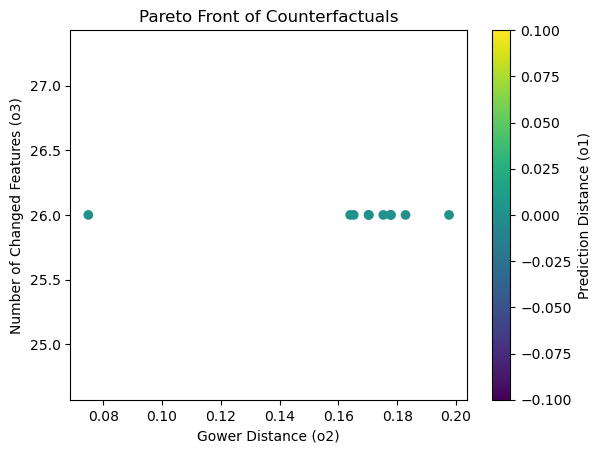

In [17]:
import matplotlib.pyplot as plt

# Plot objective values of Pareto front
F = res.F  # Objective values from pymoo result
plt.scatter(F[:, 1], F[:, 2], c=F[:, 0], cmap='viridis')
plt.xlabel('Gower Distance (o2)')
plt.ylabel('Number of Changed Features (o3)')
plt.colorbar(label='Prediction Distance (o1)')
plt.title('Pareto Front of Counterfactuals')
plt.show()

In [21]:
from pymoo.indicators.hv import HV

# Reference point: maximal values of objectives plus a margin
ref_point = np.max(F, axis=0) + 0.1
hv = HV(ref_point=ref_point)
print("Hypervolume:", hv(F))


Hypervolume: 0.00026232726818414213


In [23]:
# For parameter tuning, use libraries like irace (R) or Optuna (Python)
# Example: Use Optuna for tuning population size, mutation rates, etc.

import optuna

def objective(trial):
    pop_size = trial.suggest_int('pop_size', 20, 100)
    n_gen = trial.suggest_int('n_gen', 50, 200)
    # ... set up and run evolutionary algorithm ...
    # Return negative HV (since Optuna minimizes)
    return -hv.do(F)

study = optuna.create_study()
study.optimize(objective, n_trials=20)
print("Best parameters:", study.best_params)

/Users/bartosz/miniforge3/envs/explainit_dev/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-08-03 11:09:13,859] A new study created in memory with name: no-name-24f677b3-2bfb-4d23-891f-1aeceead792a
[I 2025-08-03 11:09:13,860] Trial 0 finished with value: -0.00026232726818414213 and parameters: {'pop_size': 64, 'n_gen': 69}. Best is trial 0 with value: -0.00026232726818414213.
[I 2025-08-03 11:09:13,860] Trial 1 finished with value: -0.00026232726818414213 and parameters: {'pop_size': 73, 'n_gen': 87}. Best is trial 0 with value: -0.00026232726818414213.
[I 2025-08-03 11:09:13,863] Trial 2 finished with value: -0.00026232726818414213 and parameters: {'pop_size': 43, 'n_gen': 172}. Best is trial 0 with value: -0.00026232726818414213.
[I 2025-08-03 11:09:13,869] Trial 3 finished with value: -0.000

Best parameters: {'pop_size': 64, 'n_gen': 69}


In [29]:
import numpy as np
from scipy.optimize import minimize
from typing import List, Tuple, Optional, Callable
import copy

class MINLPSolver:
    def __init__(self, objective_func: Callable, constraints: List[Callable], 
                 bounds: List[Tuple], integer_vars: List[int]):
        """
        MINLP Solver using Branch-and-Bound
        
        Args:
            objective_func: Function to minimize f(x)
            constraints: List of constraint functions g(x) <= 0
            bounds: List of (min, max) bounds for each variable
            integer_vars: List of indices for integer variables
        """
        self.objective_func = objective_func
        self.constraints = constraints
        self.bounds = bounds
        self.integer_vars = integer_vars
        self.best_solution = None
        self.best_value = float('inf')
        
    def solve_relaxed_problem(self, bounds: List[Tuple]) -> Tuple[Optional[np.ndarray], float]:
        """Solve the continuous relaxation of the problem"""
        
        # Initial guess
        x0 = np.array([(b[0] + b[1]) / 2 for b in bounds])
        
        # Convert constraints to scipy format
        cons = []
        for constraint in self.constraints:
            cons.append({'type': 'ineq', 'fun': lambda x, c=constraint: -c(x)})
        
        try:
            result = minimize(
                self.objective_func,
                x0,
                method='SLSQP',
                bounds=bounds,
                constraints=cons,
                options={'maxiter': 1000}
            )
            
            if result.success:
                return result.x, result.fun
            else:
                return None, float('inf')
                
        except Exception:
            return None, float('inf')
    
    def is_integer_feasible(self, solution: np.ndarray, tolerance: float = 1e-6) -> bool:
        """Check if solution satisfies integer constraints"""
        for i in self.integer_vars:
            if abs(solution[i] - round(solution[i])) > tolerance:
                return False
        return True
    
    def branch_and_bound(self, bounds: List[Tuple], depth: int = 0, max_depth: int = 20) -> None:
        """Branch-and-bound algorithm"""
        
        if depth > max_depth:
            return
        
        # Solve relaxed problem
        solution, obj_value = self.solve_relaxed_problem(bounds)
        
        if solution is None or obj_value >= self.best_value:
            return  # Prune this branch
        
        # Check if solution is integer feasible
        if self.is_integer_feasible(solution):
            if obj_value < self.best_value:
                self.best_value = obj_value
                self.best_solution = solution.copy()
            return
        
        # Branch on the most fractional integer variable
        max_frac = 0
        branch_var = None
        for i in self.integer_vars:
            frac = abs(solution[i] - round(solution[i]))
            if frac > max_frac:
                max_frac = frac
                branch_var = i
        
        if branch_var is None:
            return
        
        # Create two branches
        floor_val = int(np.floor(solution[branch_var]))
        ceil_val = int(np.ceil(solution[branch_var]))
        
        # Left branch: x[branch_var] <= floor_val
        left_bounds = copy.deepcopy(bounds)
        left_bounds[branch_var] = (bounds[branch_var][0], min(bounds[branch_var][1], floor_val))
        
        # Right branch: x[branch_var] >= ceil_val
        right_bounds = copy.deepcopy(bounds)
        right_bounds[branch_var] = (max(bounds[branch_var][0], ceil_val), bounds[branch_var][1])
        
        # Recursively solve branches
        self.branch_and_bound(left_bounds, depth + 1, max_depth)
        self.branch_and_bound(right_bounds, depth + 1, max_depth)
    
    def solve(self) -> Tuple[Optional[np.ndarray], float]:
        """Solve the MINLP problem"""
        self.best_solution = None
        self.best_value = float('inf')
        
        self.branch_and_bound(self.bounds)
        
        return self.best_solution, self.best_value

# Example usage
def example_minlp():
    """Example: Minimize x1^2 + x2^2 subject to x1 + x2 >= 3, x1 integer"""
    
    # Objective function: minimize x1^2 + x2^2
    def objective(x):
        return x[0]**2 + x[1]**2
    
    # Constraints: x1 + x2 >= 3  ->  -(x1 + x2 - 3) <= 0
    def constraint1(x):
        return -(x[0] + x[1] - 3)
    
    # Variable bounds: 0 <= x1 <= 5, 0 <= x2 <= 5
    bounds = [(0, 5), (0, 5)]
    
    # x1 is integer (index 0)
    integer_vars = [0]
    
    # Create and solve
    solver = MINLPSolver(objective, [constraint1], bounds, integer_vars)
    solution, obj_value = solver.solve()
    
    print(f"Optimal solution: {solution}")
    print(f"Optimal value: {obj_value}")
    
    return solution, obj_value

if __name__ == "__main__":
    example_minlp()

Optimal solution: [2. 1.]
Optimal value: 4.999999999999976
